In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: str

In [3]:
def calculate_sr(state: BatsmanState) -> BatsmanState:
    strike_rate = (state['runs'] / state['balls']) * 100
    return {'strike_rate': strike_rate}

In [4]:
def calculate_bpb(state: BatsmanState) -> BatsmanState:
    balls_per_boundary = state['balls'] / (state['fours'] + state['sixes']) 
    return {'balls_per_boundary': balls_per_boundary}

In [5]:
def calculate_bp(state: BatsmanState) -> BatsmanState:
    boundary_percentage = ((state['fours'] * 4 + state['sixes'] * 6) / state['runs']) * 100
    return {'boundary_percentage': boundary_percentage}

In [6]:
def summary(state: BatsmanState) -> BatsmanState:
    summary = f"""
    Strike Rate: {state['strike_rate']} \n
    Balls per Boundary: {state['balls_per_boundary']} \n
    Boundary Percentage: {state['boundary_percentage']}
"""
    return {'summary': summary}

In [7]:
graph = StateGraph(BatsmanState)

graph.add_node('CalculateStrikeRate', calculate_sr)
graph.add_node('CalculateBallsPerBoundary', calculate_bpb)
graph.add_node('CalculateBoundaryPercentage', calculate_bp)
graph.add_node('Summary', summary)

graph.add_edge(START, 'CalculateStrikeRate')
graph.add_edge(START, 'CalculateBallsPerBoundary')
graph.add_edge(START, 'CalculateBoundaryPercentage')
graph.add_edge('CalculateStrikeRate', 'Summary')
graph.add_edge('CalculateBallsPerBoundary', 'Summary')
graph.add_edge('CalculateBoundaryPercentage', 'Summary')
graph.add_edge('Summary', END)

workflow = graph.compile()

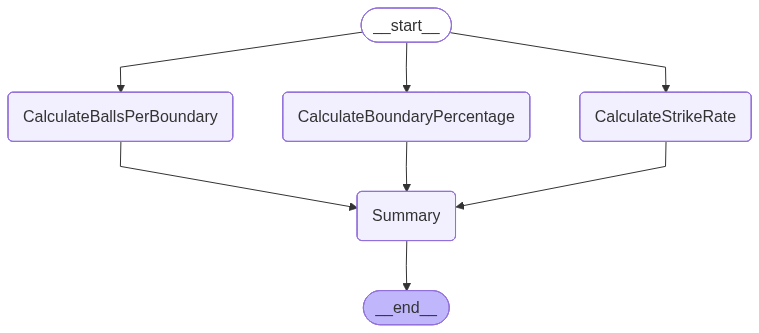

In [8]:
workflow

In [9]:
initial_state = {'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4}
final_state = workflow.invoke(initial_state)

In [10]:
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'strike_rate': 200.0, 'balls_per_boundary': 5.0, 'boundary_percentage': 48.0, 'summary': '\n    Strike Rate: 200.0 \n\n    Balls per Boundary: 5.0 \n\n    Boundary Percentage: 48.0\n'}


In [11]:
print(final_state['summary'])


    Strike Rate: 200.0 

    Balls per Boundary: 5.0 

    Boundary Percentage: 48.0

